

# Climate Change - Temperatures and Precipitation

Investigating data on climate change, or the long-term shifts in temperatures and weather patterns!

In [55]:
# Install libraries and dataset
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
np.set_printoptions(legacy='1.13')

import warnings
warnings.simplefilter('ignore')

import plotly.graph_objects as go

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Part 1: Temperatures

We can start to learn about climate change just by analyzing public records of different cities' temperature and precipitation over time.

We will analyze a collection of historical daily temperature and precipitation measurements from weather stations in 210 U.S. cities. The dataset was compiled by Yuchuan Lai and David Dzombak [1]; a description of the data from the original authors and the data itself is available [here](https://kilthub.cmu.edu/articles/dataset/Compiled_daily_temperature_and_precipitation_data_for_the_U_S_cities/7890488). 

[1] Lai, Yuchuan; Dzombak, David (2019): Compiled historical daily temperature and precipitation data for selected 210 U.S. cities. Carnegie Mellon University. Dataset.

### Part 1, Section 1: Cities

Loading information about the `cities` and preview the first few rows.

In [56]:
cities = Table.read_table('city_info.csv', index_col=0)
cities.show(3)

Name,ID,Lat,Lon,Stn.Name,Stn.stDate,Stn.edDate
Lander,USW00024021,42.8153,-108.726,LANDER WBO,1892-01-01,1946-05-28
Lander,USW00024021,42.8153,-108.726,LANDER HUNT FIELD,1946-05-29,2021-12-31
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE WBO,1871-01-01,1935-08-31


The `cities` table has one row per weather station and the following columns:

1. `"Name"`: The name of the US city
2. `"ID"`: The unique identifier for the US city
3. `"Lat"`: The latitude of the US city (measured in degrees of latitude)
4. `"Lon"`: The longitude of the US city (measured in degrees of longitude)
4. `"Stn.Name"`: The name of the weather station in which the data was collected
5. `"Stn.stDate"`: A string representing the date of the first recording at that particular station
6. `"Stn.edDate"`: A string representing the date of the last recording at that particular station

The data lists the weather stations at which temperature and precipitation data were collected. Note that although some cities have multiple weather stations, only one station records data for a city at any given time. Thus, we are able to just focus on the cities themselves.

<!-- BEGIN QUESTION -->

---

**A scatter plot that plots the latitude and longitude of every city in the `cities` table so that the result places northern cities at the top and western cities at the left.**


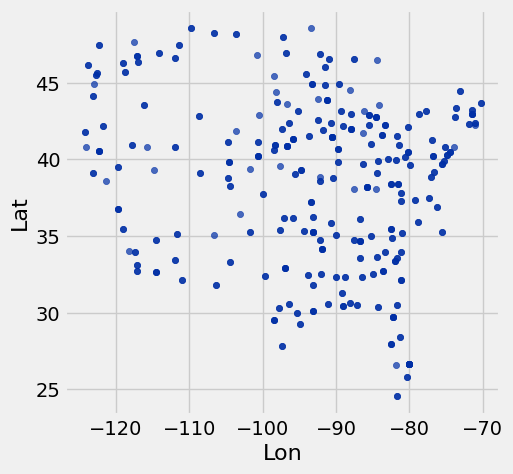

In [57]:
cities.scatter('Lon', 'Lat')

<!-- BEGIN QUESTION -->

---

**Points projected onto a map of the U.S.**


In [58]:
fig = go.Figure(data=go.Scattergeo(
        lon = cities.column('Lon'),
        lat = cities.column('Lat'),
        text = cities.column('Name'),
        mode = 'markers'))

fig.update_layout(geo_scope='usa', width=800, height=500, margin={'r': 0, 't': 0, 'l': 0, 'b': 0})
fig.show()

<!-- BEGIN QUESTION -->

---

**Analysis**


It does not appear that these city locations are sampled uniformly at random from all land in the continental United States. The eastern U.S. has many more sampled locations, while the Midwest and West parts have far fewer points. This pattern indicates that the dataset was likely sampled according to population density. If the cities were sampled uniformly at random, we would expect the locations to be spread roughly evenly across the U.S. instead of clustering in more populated regions.

<!-- END QUESTION -->

---

**Assigning `num_unique_cities` to the number of unique cities that appear in the `cities` table.**


In [59]:
num_unique_cities = cities.group("ID").num_rows

# Do not change this line
print(f"There are {num_unique_cities} unique cities that appear within the dataset.")

There are 210 unique cities that appear within the dataset.


In order to investigate further, it will be helpful to determine what region of the United States each city was located in: Northeast, Northwest, Southeast, or Southwest.  This project uses the following geographical boundaries:

<img src= "usa_coordinates.png" alt="USA Coordinate Map" width="600"/>

1. A station is located in the `"Northeast"` region if its latitude is above or equal to 40 degrees and its longitude is greater than or equal to -100 degrees.
2. A station is located in the `"Northwest"` region if its latitude is above or equal to 40 degrees and its longitude is less than -100 degrees.
3. A station is located in the `"Southeast"` region if its latitude is below 40 degrees and its longitude is greater than or equal to -100 degrees.
4. A station is located in the `"Southwest"` region if its latitude is below 40 degrees and its longitude is less than -100 degrees.

---

**Defining `coordinates_to_region` function. It takes in two arguments, a city's latitude (`lat`) and longitude (`lon`) coordinates, and outputs a string representing the region it is located in.**


In [60]:
def coordinates_to_region(lat, lon):
    if lat>=40:
        if lon>=-100:
            return "Northeast"
        else:
            return "Northwest"
    if lat<40:
        if lon>=-100:
            return "Southeast"
        else:
            return "Southwest"

---

**Adding a new column in `cities` labeled `Region` that contains the region in which the city is located (using the  `coordinates_to_region` function defined earlier).**


In [61]:
regions_array = cities.apply(coordinates_to_region, ('Lat', 'Lon'))
cities = cities.with_column('Region', regions_array)
cities.show(5)

Name,ID,Lat,Lon,Stn.Name,Stn.stDate,Stn.edDate,Region
Lander,USW00024021,42.8153,-108.726,LANDER WBO,1892-01-01,1946-05-28,Northwest
Lander,USW00024021,42.8153,-108.726,LANDER HUNT FIELD,1946-05-29,2021-12-31,Northwest
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE WBO,1871-01-01,1935-08-31,Northwest
Cheyenne,USW00024018,41.1519,-104.806,CHEYENNE MUNICIPAL ARPT,1935-09-01,2021-12-31,Northwest
Wausau,USW00014897,44.9258,-89.6256,Wausau Record Herald,1896-01-01,1941-12-31,Northeast


Confirming `coordinates_to_region` function works correctly and successfully adds the `Region` column to the `cities` table.

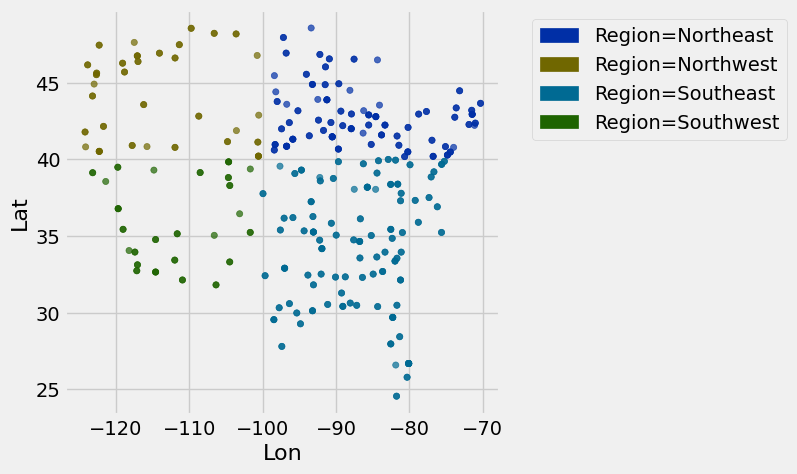

In [62]:
# Just run this cell
cities.scatter("Lon", "Lat", group="Region")

### Part 1, Section 2: Welcome to Phoenix, Arizona

Each city has a different CSV file full of daily temperature and precipitation measurements. The file for Phoenix, Arizona is included with this project as `phoenix.csv`. 

Since Phoenix is located on the upper edge of the Sonoran Desert, it has some impressive temperatures.

The 'phoenix' table has one row per day and the following columns:

1. `"Date"`: The date (a string) representing the date of the recording in **YYYY-MM-DD** format
2. `"tmax"`: The maximum temperature for the  day (°F)
3. `"tmin"`: The minimum temperature for the day (°F)
4. `"prcp"`: The recorded precipitation for the day (inches)

In [63]:
phoenix = Table.read_table("phoenix.csv", index_col=0)
phoenix.show(3)

Date,tmax,tmin,prcp
1896-01-01,66,30,0
1896-01-02,64,30,0
1896-01-03,68,30,0


---

**Assigning the variable `largest_2010_range_date` to the date of the **largest temperature range** in Phoenix, Arizona for any day between January 1st, 2010 and December 31st, 2010.**

In [64]:
phoenix_2010_table = phoenix.where('Date', are.containing('2010'))
phoenix_with_ranges_2010 = phoenix_2010_table.with_column('range',phoenix_2010_table.column('tmax') - phoenix_2010_table.column('tmin'))
largest_2010_range_date = phoenix_with_ranges_2010.sort('range', descending =True).row(0).item(0)
largest_2010_range_date

'2010-06-24'

We can look back to our `phoenix` table to check the temperature readings for our `largest_2010_range_date` to see if anything special is going on. 

In [65]:
# Just run this cell
phoenix.where("Date", largest_2010_range_date)

Date,tmax,tmin,prcp
2010-06-24,113,79,0


ZOO WEE MAMA! Look at the maximum temperature for that day. That's hot.

The function `extract_year_from_date` takes a date string in the **YYYY-MM-DD** format and returns an integer representing the **year**. The function `extract_month_from_date` takes a date string and returns a string describing the month.

In [66]:
# Just run this cell
import calendar

def extract_year_from_date(date):
    """Returns an integer corresponding to the year of the input string's date."""
    return int(date[:4])

def extract_month_from_date(date):
    "Return an abbreviation of the name of the month for a string's date."
    month = date[5:7]
    return f'{month} ({calendar.month_abbr[int(date[5:7])]})'


# Example
print('2022-04-01 has year', extract_year_from_date('2022-04-01'),
      'and month', extract_month_from_date('2022-04-01'))

2022-04-01 has year 2022 and month 04 (Apr)


---

**Adding two new columns called "Year" and "Month" to the `phoenix` table that contain the year as an integer and the month as a string (such as "04 (Apr)") for each day, respectively.**


In [67]:
years_array = phoenix.apply(extract_year_from_date, 'Date')
months_array = phoenix.apply(extract_month_from_date, 'Date')
phoenix = phoenix.with_columns(
    'Year', years_array,
    'Month', months_array,
)
phoenix.show(5)

Date,tmax,tmin,prcp,Year,Month
1896-01-01,66,30,0,1896,01 (Jan)
1896-01-02,64,30,0,1896,01 (Jan)
1896-01-03,68,30,0,1896,01 (Jan)
1896-01-04,69,34,0,1896,01 (Jan)
1896-01-05,70,46,0,1896,01 (Jan)


<!-- BEGIN QUESTION -->

---

**Overlaid line plot of the average maximum temperature and average minimum temperature for each year between 1900 and 2020 (both ends inclusive).** 


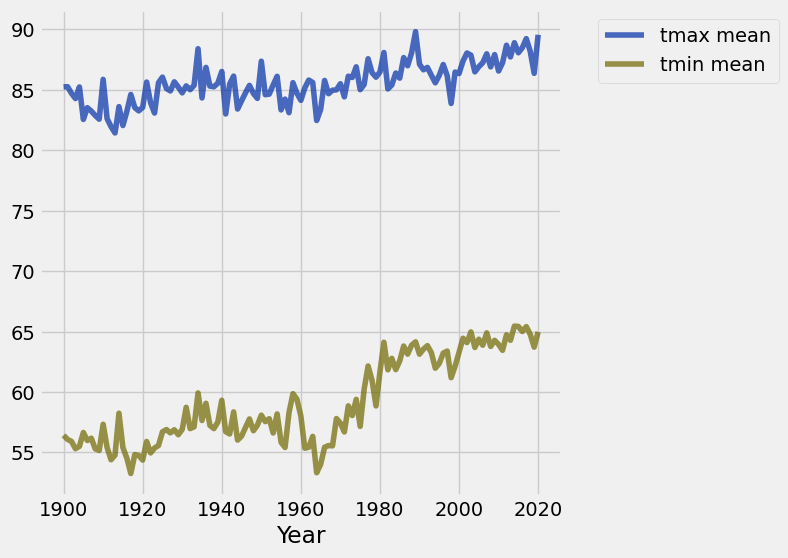

In [68]:
t = phoenix.group('Year', np.mean)
u = t.where('Year', are.between(1900, 2021))
v = u.select('Year', 'tmax mean', 'tmin mean')
v.plot('Year')

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

**Note:** Although still hotly debated (pun intended), many climate scientists agree that the effects of climate change began to surface in the early 1960s as a result of elevated levels of greenhouse gas emissions. How does the graph support the claim that modern-day global warming began in the early 1960s? 


It shows that both the average minimum and maximum temperature per year has been increasing over time. Starting from 1960, you can see a spike in the minimum average temperature with a significant increase in the rate of temperature rising.

<!-- END QUESTION -->

Averaging temperatures across an entire year can obscure some effects of climate change. For example, if summers get hotter but winters get colder, the annual average may not change much. So, we investigate how average **monthly** maximum temperatures have changed over time in Phoenix. 

---

**Creating a `monthly_increases` table with one row per month and the following four columns in order**: 
1. `"Month"`: The month (such as `"02 (Feb)"`)
2. `"Past"`: The average max temperature in that month from 1900-1960 (both ends inclusive)
3. `"Present"`: The average max temperature in that month from 2019-2021 (both ends inclusive)
4. `"Increase"`: The difference between the present and past average max temperatures in that month

The period refers to whether the year is in the `"Past"`, `"Present"`, or `"Other"` category. 

In [69]:
def period(year):
    "Output if a year is in the Past, Present, or Other."
    if 1900 <= year <= 1960:
        return "Past"
    elif 2019 <= year <= 2021:
        return "Present"
    else:
        return "Other"
        
added = phoenix.with_column('Period', phoenix.apply(period, 'Year'))
monthly_increases = Table().with_columns('Month', added.group('Month').column('Month'),'Past', added.where('Year', are.between(1900, 1961)).group('Month', np.mean).column('tmax mean'),
'Present', added.where('Year', are.between(2019, 2022)).group('Month', np.mean).column('tmax mean'))
monthly_increases = monthly_increases.with_column('Increase', monthly_increases.column('Present') - monthly_increases.column('Past')) 
monthly_increases.show()

Month,Past,Present,Increase
01 (Jan),65.0164,67.8312,2.81479
02 (Feb),68.8485,69.1859,0.337362
03 (Mar),74.6499,75.9796,1.32965
04 (Apr),82.6421,88.4,5.75792
05 (May),91.4299,94.571,3.14104
06 (Jun),101.166,105.734,4.56832
07 (Jul),103.599,107.245,3.64654
08 (Aug),101.416,107.384,5.96769
09 (Sep),97.6874,101.238,3.55035
10 (Oct),86.798,90.1667,3.36868


### February in Phoenix

The `"Past"` column values are averaged over many decades, and so they are reliable estimates of the average high temperatures in those months before the effects of modern climate change. However, the `"Present"` column is based on only three years of observations. February, the shortest month, has the fewest total observations: only 85 days. Run the following cell to see this.

In [70]:
# Just run this cell
feb_present = phoenix.where('Year', are.between_or_equal_to(2019, 2021)).where('Month', '02 (Feb)')
feb_present.num_rows

85

Compared to the other months, the increase for the month of February is quite small; the February difference is very close to zero. Run the following cell to print out our observed difference.

In [71]:
# Just run this cell
print(f"February Difference: {monthly_increases.row(1).item('Increase')}")

February Difference: 0.3373623297258632


Perhaps that small difference is somehow due to chance! To investigate this idea requires a thought experiment.

We can observe all of the February maximum temperatures from 2019 to 2021 (the present period), so we have access to the census; there's no random sampling involved. But, we can imagine that if more years pass with the same present-day climate, there would be different but similar maximum temperatures in future February days. From the data we observe, we can try to estimate the **average maximum February temperature** in this imaginary collection of all future February days that would occur in our modern climate, assuming the climate doesn't change any further and many years pass.

We can also imagine that the maximum temperature each day is like a **random draw from a distribution of max daily temperatures for that month**. Treating actual observations of natural events as if they were each *randomly* sampled from some unknown distribution is a simplifying assumption. These temperatures were not actually sampled at random—instead they occurred due to the complex interactions of the Earth's climate—but treating them as if they were random abstracts away the details of this naturally occurring process and allows us to carry out statistical inference.  Conclusions are only as valid as the assumptions upon which they rest, but in this case thinking of daily temperatures as random samples from some unknown climate distribution seems at least plausible.

If we assume that the **actual temperatures were drawn at random from some large population of possible February days** in our modern climate, then we can not only estimate the population average of this distribution, but also quantify our uncertainty about that estimate using a confidence interval.

**We will now compute the confidence interval of the present February average max daily temperature.** To unpack this statement, we are saying that this confidence interval is looking at present-day February conditions (think about which table is relevant to this), and the confidence interval is for present-day February average max daily temperatures. We will compare this confidence interval to the historical average (ie. the `"Past"` value in our `monthly_increases` table). How will we do the comparison? Well, since we are essentially interested in seeing if the average February max daily temperatures have ***changed*** since the past, we care about whether the historical average lies within the confidence interval we create. 

<!-- BEGIN QUESTION -->

---

**Defined Null and Alternative Hypotheses:**


Null Hypothesis: The true average maximum February temperature at present day is equal to the historical average maximum February temperature. Any observed difference is just due to random chance. 

Alternative Hypothesis: The true average maximum February temperature at present day is different from the historical average maximum February temperature.

<!-- END QUESTION -->

---

**The function `make_ci` takes a one-column table `tbl` containing sample observations and a confidence `level` percentage such as 95 or 99.** 

**It returns an array containing the lower and upper bound in that order, of a confidence interval for the population mean constructed using 5,000 bootstrap resamples.**

In [72]:
def make_ci(tbl, level):
    """Compute a level% confidence interval of the average of the population for 
    which column 0 of Table tbl contains a sample. This function should return an 
    array of the lower and upper bounds of the confidence interval.
    """
    stats = make_array()
    for k in np.arange(5000):
        stat = np.mean(tbl.sample().column(0))
        stats = np.append(stats, stat)
    lower_bound = ((100-level)/2)
    upper_bound = 100 - lower_bound
    return make_array(percentile(lower_bound, stats), percentile(upper_bound, stats))

# Call make_ci on the max temperatures in present-day February to find the lower and upper bound of a 99% confidence interval.
feb_present_ci = make_ci(feb_present.select('tmax'), 99)
feb_present_ci

array([ 67.05411765,  71.28      ])

<!-- BEGIN QUESTION -->

---

**Analysis:** The `feb_present_ci` 99% confidence interval contains the observed past February average maximum temperature of 68.8485 (from the `monthly_increases` table). What conclusion can we draw about the effect of climate change on February maximum temperatures in Phoenix from this information? Note: use a 1% p-value cutoff.

As the observed temperature of 68.8485 lies within the 99% confidence interval (from 1% p value cutoff), we fail to reject the null hypothesis. We do not have suﬀicient evidence that the maximum February temperature in Phoenix has changed from its historical average.

<!-- END QUESTION -->

### All Months

---

Now we repeat the process of seeing whether the **past average for each month** is **contained within the 99% confidence interval** of the **present average**. 

In [73]:
comparisons = make_array()
months = monthly_increases.column('Month')
for month in months:
    past_average = monthly_increases.where('Month', month).column('Past').item(0)
    present_observations = phoenix.where('Year', are.between(2019, 2022)).where('Month', month)
    present_ci = make_ci(present_observations.select('tmax'), 99)
    
    # Do not change the code below this line
    GREEN_BOLD = '\033[1;32m'
    RED_BOLD = '\033[1;31m'
    RESET_STYLE = '\033[0m'
    within = (past_average >= present_ci.item(0)) and (past_average <= present_ci.item(1))
    if within:
        comparison = f'{GREEN_BOLD}contained{RESET_STYLE}'
    else:
        comparison = f'{RED_BOLD}NOT contained{RESET_STYLE}'
    comparisons = np.append(comparisons, comparison)
    
    print(f'For {month} the past avg {round(past_average, 1)} is {comparison} in the interval '
           f'{np.round(present_ci, 1)}, the 99% CI of the present avg.\n')

For 01 (Jan) the past avg 65.0 is NOT contained in the interval [ 66.3  69.3], the 99% CI of the present avg.

For 02 (Feb) the past avg 68.8 is contained in the interval [ 66.8  71.3], the 99% CI of the present avg.

For 03 (Mar) the past avg 74.6 is contained in the interval [ 74.   77.8], the 99% CI of the present avg.

For 04 (Apr) the past avg 82.6 is NOT contained in the interval [ 86.3  90.4], the 99% CI of the present avg.

For 05 (May) the past avg 91.4 is NOT contained in the interval [ 92.5  96.5], the 99% CI of the present avg.

For 06 (Jun) the past avg 101.2 is NOT contained in the interval [ 104.3  107.2], the 99% CI of the present avg.

For 07 (Jul) the past avg 103.6 is NOT contained in the interval [ 105.5  108.8], the 99% CI of the present avg.

For 08 (Aug) the past avg 101.4 is NOT contained in the interval [ 105.8  108.9], the 99% CI of the present avg.

For 09 (Sep) the past avg 97.7 is NOT contained in the interval [  99.1  103.1], the 99% CI of the present avg.

<!-- BEGIN QUESTION -->

---

**Summary about the monthly average maximum temperature in historical (1900-1960) vs. modern (2019-2021) times in the twelve months:**.

We can conclude that for most months, the true average maximum temperature today differs from its historical average. After running the test, we found that the past averages for February, March, and December were contained in the 99% confidence interval of the present average. For these months we would fail to reject the null hypothesis. For the other months, the past averages were not in the 99% confidence interval, and so we would reject the null hypothesis in these cases. One observation is that for all the past averages not contained in the present confidence interval, all these averages were lower than the lower bound, never higher than the upper bound. Also, the months that had a past average value not contained in the confidence interval were all in the summer months while months with past averages that were contained were generally winter months. Thus, we can infer from our analysis that in general the average maximum temperature has increased over time - it’s getting hotter, especially during summer.

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# Part 2: Drought

According to the [United States Environmental Protection Agency](https://www.epa.gov/climate-indicators/southwest), "Large portions of the Southwest have experienced drought conditions since weekly Drought Monitor records began in 2000. For extended periods from 2002 to 2005 and from 2012 to 2020, nearly the entire region was abnormally dry or even drier." 

Assessing the impact of drought is challenging with just city-level data because so much of the water that people use is transported from elsewhere, but we'll explore the data we have and see what we can learn.

The `southwest.csv` file contains total annual precipitation for 13 cities in the southwestern United States for each year from 1960 to 2021. This dataset is aggregated from the daily data and includes only the Southwest cities from the original dataset that have consistent precipitation records back to 1960.

In [74]:
southwest = Table.read_table('southwest.csv')
southwest.show(5)

City,Year,Total Precipitation
Albuquerque,1960,8.12
Albuquerque,1961,8.87
Albuquerque,1962,5.39
Albuquerque,1963,7.47
Albuquerque,1964,7.44


---

**Creating a table `totals` that has one row for each year in chronological order. It contains the following columns:**
1. `"Year"`: The year (a number)
2. `"Precipitation"`: The total precipitation in all 13 southwestern cities that year


In [75]:
totals = southwest.drop("City").group("Year", np.sum).relabeled("Total Precipitation sum","Precipitation")
totals

Year,Precipitation
1960,149.58
1961,134.82
1962,130.41
1963,132.18
1964,123.41
1965,187.53
1966,120.27
1967,179.02
1968,136.25
1969,191.72


Run the cell below to plot the total precipitation in these cities over time, so that we can try to spot the drought visually. As a reminder, the drought years given by the EPA were  (2002-2005) and (2012-2020).

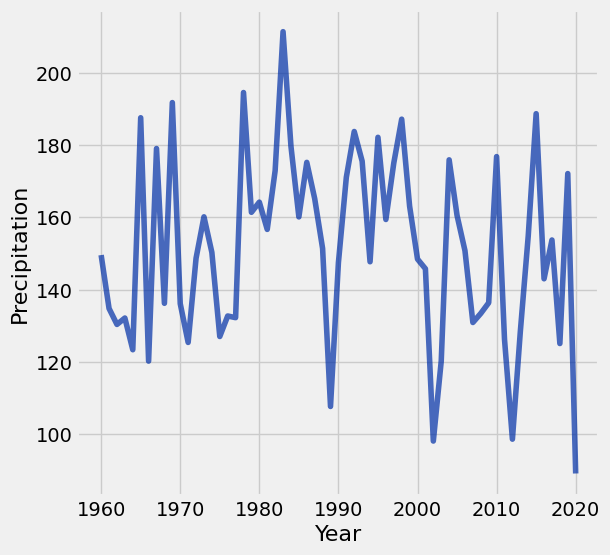

In [76]:
# Just run this cell
totals.plot("Year", "Precipitation")

This plot isn't very revealing. Each year has a different amount of precipitation, and there is quite a bit of variability across years, as if each year's precipitation is a random draw from a distribution of possible outcomes. 

Could it be that these so-called "drought conditions" from 2002-2005 and 2012-2020 can be explained by chance? In other words, could it be that the annual precipitation amounts in the Southwest for these drought years are like **random draws from the same underlying distribution** as for other years? Perhaps nothing about the Earth's precipitation patterns has really changed, and the Southwest U.S. just happened to experience a few dry years close together. 

To assess this idea, let's conduct an A/B test in which **each year's total precipitation** is an outcome, and the condition is **whether or not the year is in the EPA's drought period**.

This `drought_label` function distinguishes between drought years as described in the U.S. EPA statement above (2002-2005 and 2012-2020) and other years. Note that the label "other" is perhaps misleading, since there were other droughts before 2000, such as the massive [1988 drought](https://en.wikipedia.org/wiki/1988%E2%80%9390_North_American_drought) that affected much of the U.S. However, if we're interested in whether these modern drought periods (2002-2005 and 2012-2020) are *normal* or *abnormal*, it makes sense to distinguish the years in this way. 

In [77]:
def drought_label(n):
    """Return the label for an input year n."""
    if 2002 <= n <= 2005 or 2012 <= n <= 2020:
        return 'drought'
    else:
        return 'other'

<!-- BEGIN QUESTION -->

---

**Defining null and alternative hypotheses for an A/B test that investigates whether drought years are **drier** (have less precipitation) than other years.**

**Null hypothesis:** The total annual precipitation drawn from both drought and non-drought years comes from the same underlying distribution. Any observed difference in total precipitation levels is due to random chance.

**Alternative hypothesis:** The total annual precipitation drawn from drought years is from a different distribution than the non-drought years. The average annual precipitation levels for drought years are less than the average annual precipitation levels for non-drought years.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

**Defining the table `drought`.** 
It should contain one row per year and the following two columns:
- `"Label"`: Denotes if a year is part of a `"drought"` year or an `"other"` year
- `"Precipitation"`: The sum of the total precipitation in 13 Southwest cities that year

**AND**

**Constructing an overlaid histogram of two observed distributions: the total precipitation in drought years and the total precipitation in other years.** 

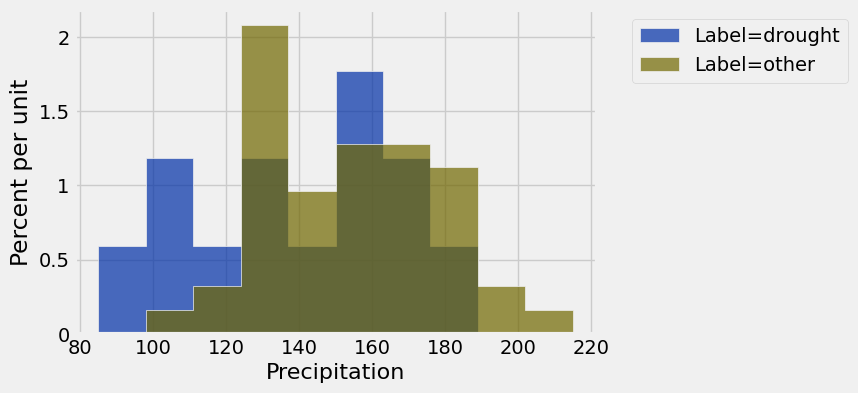

In [78]:
bins = np.arange(85, 215+1, 13)
year_labels = totals.apply(drought_label, "Year")
drought = Table().with_columns(
    'Label', year_labels,
    'Precipitation', totals.column('Precipitation'),
)
drought.hist('Precipitation', bins = bins, group = 'Label')

<!-- BEGIN QUESTION -->

---

Fellow climate scientists Noah and Sarah point out that there are more **other** years than **drought** years, and so measuring the difference between total precipitation will always favor the **other** years. They conclude that all of the options above involving **total** precipitation are invalid test statistic choices. Do you agree with them? Why or why not?

I agree. In a permutation test, the number of labels in each group is fixed, so “other” years will always include more years than “drought” years. Because of this imbalance, the total precipitation in “other” years will almost always be larger simply due to having more observations, even if both groups come from the same underlying distribution. This means a test statistic based on totals would not be centered at 0 (H0: no difference) under the null hypothesis, so we could not tell whether differences are real or just due to unequal group sizes. Using average precipitation is a better option because when we compare averages, the difference between groups will be centered around 0 under the null hypothesis, allowing us to know whether drought years are genuinely drier than other years.

<!-- END QUESTION -->

Checking `drought` table. It should have two columns `"Label"` and `"Precipitation"` with 61 rows, 13 of which are for `"drought"` years.

In [79]:
drought.show(3)

Label,Precipitation
other,149.58
other,134.82
other,130.41


In [80]:
drought.group('Label')

Label,count
drought,13
other,48


---

For our A/B test, we'll use the difference between the average precipitation in drought years and the average precipitation in other years as our test statistic:

$$\text{average precipitation in ``drought" years} - \text{average precipitation in ``other" years}$$

The function `test_statistic` implemented below takes in a two-column table `t` with one row per year and two columns:
- `"Label"`: the label for that year (either `"drought"` or `"other"`)
- `"Precipitation"`: the total precipitation in the 13 Southwest cities that year. 


In [81]:
def test_statistic(t):
    avg_drought = np.mean(t.where('Label', 'drought').column('Precipitation'))
    avg_other = np.mean(t.where('Label', 'other').column('Precipitation'))
    return avg_drought - avg_other
observed_statistic = test_statistic(drought)
observed_statistic

-15.856714743589748

Now that we have defined our hypotheses and test statistic, we are ready to conduct our hypothesis test. We’ll start by defining a function to simulate the test statistic under the null hypothesis, and then call that function 5,000 times to construct an empirical distribution under the null hypothesis.

---

**The `simulate_precipitation_null` function simulates the null hypothesis once (not 5,000 times) and returns the value of the test statistic for that simulated sample.**


In [82]:
def simulate_precipitation_null():
    shuffled_values = drought.sample(with_replacement = False).column('Precipitation')
    shuffled_table = drought.with_column('Precipitation', shuffled_values)
    return test_statistic(shuffled_table)

# Run your function a couple times to make sure that it works
simulate_precipitation_null()

8.4347756410256522

---

**Now we compute 5,000 values of the test statistic under the null hypothesis and store the result in the array `sampled_stats`.**


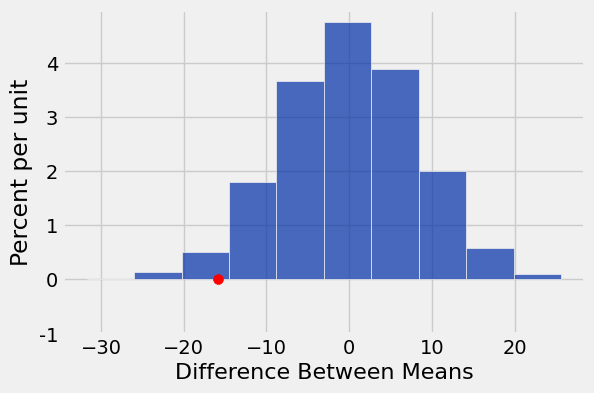

In [83]:
sampled_stats = make_array()

repetitions = 5000
for i in np.arange(repetitions):
    one_simulated_value = simulate_precipitation_null()
    sampled_stats = np.append(sampled_stats, one_simulated_value)

# Do not change these lines
Table().with_column('Difference Between Means', sampled_stats).hist()
plt.scatter(observed_statistic, 0, c="r", s=50);
plt.ylim(-0.01);

---

**Computing the p-value for this hypothesis test, and assigning it to the variable `precipitation_p_val`.**


In [84]:
precipitation_p_val = np.mean((sampled_stats <= observed_statistic))
precipitation_p_val

0.027199999999999998

<!-- BEGIN QUESTION -->

---

**Conclusion from this test using a p-value cutoff of 5%. What have we learned about the EPA's statement on drought?**


Since the p-value equals 0.0224 < 0.05, we reject the null hypothesis and conclude that the average annual precipitation in drought years is lower than in non-drought years. This supports the EPA’s statement that, during extended periods such as 2002–2005 and 2012–2020, much of the Southwest experienced abnormally dry or even drier conditions.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

**Thought:** Does the conclusion apply to the entire Southwest region of the U.S.? Why or why not?

No, the conclusion does not necessarily apply to the entire Southwest region. Our analysis is based only on the 13 cities in the dataset, so the results reflect conditions in those specific locations rather than the whole Southwest. The region has highly diverse geography, including deserts and mountains, which means precipitation patterns can vary widely from one place to another.

In addition, the cities in the dataset form a convenience sample because they were chosen for having complete historical records. This introduces potential sampling bias, such as missing important cities that might change the results or underrepresenting certain areas of the Southwest region.

Overall, the results apply only to the cities in the dataset and cannot describe the whole Southwest region of the U.S.